# QFE-COD: Quantum Frequency-Enhanced Camouflaged Object Detection
### COD10K-v3 | PVTv2-B4 + DWT + FSA + Mamba + HQCM + Q-WaveKAN + GradCAM
### vs SINetV2 Baseline | With CAM/NonCAM Classifier Stage

## Section 1: Installs & Imports

In [1]:
# ── Installs ──────────────────────────────────────────────────────────────────
import subprocess, sys
def pip(*args): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

pip('timm', 'pennylane', 'pennylane-lightning', 'PyWavelets', 'segmentation-models-pytorch',
    'albumentations', 'einops', 'torchmetrics', 'grad-cam')

print('All packages installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.0 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 108.7 MB/s eta 0:00:00


All packages installed.


In [2]:
import os, json, random, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from pathlib import Path
from PIL import Image
from collections import defaultdict
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import timm

import pennylane as qml
from pennylane import numpy as pnp

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')
print('Torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

Torch: 2.10.0+cu128 | CUDA: True


## Section 2: Config & Paths

In [3]:
# ── TRIAL SWITCH ──────────────────────────────────────────────────────────────
# Set TRIAL=True for a quick smoke-test (tiny dataset, 2 epochs, no quantum)
# Set TRIAL=False for full training run
TRIAL = False   # <─── FLIP THIS

# ── PATHS ─────────────────────────────────────────────────────────────────────
ROOT = Path('/kaggle/input/datasets/ivanomelchenkoim11/cod10k-dataset/COD10K-v3')
CKPT_DIR = Path('/kaggle/working/checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR  = Path('/kaggle/working/logs');        LOG_DIR.mkdir(exist_ok=True)
VIZ_DIR  = Path('/kaggle/working/viz');         VIZ_DIR.mkdir(exist_ok=True)

TRAIN_IMG  = ROOT / 'Train' / 'Image'
TRAIN_GT   = ROOT / 'Train' / 'GT_Object'
TRAIN_EDGE = ROOT / 'Train' / 'GT_Edge'
TEST_IMG   = ROOT / 'Test'  / 'Image'
TEST_GT    = ROOT / 'Test'  / 'GT_Object'
TEST_EDGE  = ROOT / 'Test'  / 'GT_Edge'

CAM_TRAIN_TXT  = ROOT / 'Train' / 'CAM-NonCAM_Instance_Train.txt'
CAM_TEST_TXT   = ROOT / 'Test'  / 'CAM-NonCAM_Instance_Test.txt'
CAM_TRAIN_JSON = ROOT / 'Train' / 'CAM_Instance_Train.json'
CAM_TEST_JSON  = ROOT / 'Test'  / 'CAM_Instance_Test.json'

# ── CONFIG ────────────────────────────────────────────────────────────────────
CFG = dict(
    seed          = 42,
    img_size      = 352,
    # Classifier stage
    cls_epochs    = 2  if TRIAL else 20,
    cls_bs        = 8  if TRIAL else 16,
    cls_lr        = 1e-4,
    cls_patience  = 3  if TRIAL else 7,   # early stopping patience
    # Main model stage
    epochs        = 2  if TRIAL else 50,
    bs            = 2  if TRIAL else 4,
    lr            = 1e-4,
    patience      = 5  if TRIAL else 10,  # early stopping patience
    min_delta     = 1e-4,                 # min improvement to reset counter
    use_quantum   = False if TRIAL else True,
    use_amp       = True,
    n_qubits      = 8,
    q_layers      = 4,
    lambda_bce    = 1.0,
    lambda_dice   = 1.0,
    lambda_edge   = 0.5,
    lambda_uncert = 0.3,
    trial_samples = 64,   # samples used per split in TRIAL mode
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

seed_everything(CFG['seed'])
print('Config loaded. TRIAL =', TRIAL, '| Device:', DEVICE)

Config loaded. TRIAL = False | Device: cuda


## Section 3: Dataset & DataLoader (COD10K-v3)

In [4]:
# ── DIAGNOSTIC: Inspect raw txt format before parsing ─────────────────────────
print('=== RAW FILE PREVIEW (first 10 lines) ===')
with open(CAM_TRAIN_TXT) as f:
    raw_lines = [l.rstrip() for l in f.readlines()]
for i, l in enumerate(raw_lines[:10]):
    print(f'  [{i}] {repr(l)}')
print(f'  ... total lines: {len(raw_lines)}')


# ── Auto-detect format and parse ──────────────────────────────────────────────
def parse_cam_txt(txt_path):
    cam_map = {}
    """
    Robustly parses CAM-NonCAM txt files regardless of format.

    Handles all known COD10K-v3 formats:
      Format A: 'CAM_00001.jpg 1'       (filename + int label)
      Format B: 'CAM_00001.jpg CAM'     (filename + string label)
      Format C: 'CAM_00001.jpg'         (filename only; label inferred from name prefix)
      Format D: 'CAM_00001'             (stem only; label inferred from prefix)
      Format E: '1 CAM_00001.jpg'       (int label + filename)
      Format F: 'CAM 00001 ...'         (space-separated class+id)

    Returns dict {stem: label_int} where 1=CAM, 0=NonCAM.
    """
    with open(txt_path, "r") as f:
        for line in f:
            if "[INFO]" not in line:
                continue

            line = line.replace("[INFO]", "").strip()
            parts = line.split()

            if len(parts) < 2:
                continue

            fname = parts[0]
            label = int(parts[-1])

            stem = Path(fname).stem
            cam_map[stem] = label

    return cam_map
    if not lines:
        print(f'  WARNING: {txt_path} is empty!')
        return cam_map

    # Detect format from first line
    sample = lines[0].split()

    def classify_token(tok):
        """Returns 'int_label', 'str_label', or 'filename'."""
        if tok in ('0', '1'):                           return 'int_label'
        if tok.upper() in ('CAM', 'NONCAM', 'NON-CAM',
                           'NON_CAM', 'CAMOUFLAGE',
                           'NON-CAMOUFLAGE'):           return 'str_label'
        if any(c in tok for c in ('.', '_', '/')):      return 'filename'
        if tok.isdigit():                               return 'int_label'
        return 'filename'

    def label_from_token(tok):
        tok_up = tok.upper()
        if tok in ('1',): return 1
        if tok in ('0',): return 0
        if 'NONCAM' in tok_up or 'NON' in tok_up: return 0
        if 'CAM' in tok_up:                        return 1
        return -1  # unknown

    def label_from_stem(stem):
        """Infer from filename prefix: CAM_xxx → 1, NonCAM_xxx → 0."""
        s = stem.upper()
        if s.startswith('NONCAM') or s.startswith('NON_CAM') or s.startswith('NON-CAM'):
            return 0
        if s.startswith('CAM'):
            return 1
        return 1  # default to CAM (it's a COD dataset after all)

    for line in lines:
        line = line.replace("[INFO]", "").strip()
        parts = line.split()
        if not parts: continue

        types = [classify_token(p) for p in parts]

        # Find filename token
        fname_tok  = next((p for p, t in zip(parts, types) if t == 'filename'), None)
        # Find label token (int or str)
        label_tok  = next((p for p, t in zip(parts, types) if t in ('int_label','str_label')), None)

        if fname_tok is None:
            # Entire line might be stem without extension
            fname_tok = parts[0]

        stem = Path(fname_tok).stem

        if label_tok is not None:
            label = label_from_token(label_tok)
            if label == -1:
                label = label_from_stem(stem)  # fallback
        else:
            # No explicit label → infer from filename prefix
            label = label_from_stem(stem)

        cam_map[stem] = label

    return cam_map


train_cam_map = parse_cam_txt(CAM_TRAIN_TXT)
test_cam_map  = parse_cam_txt(CAM_TEST_TXT)

n_tr_cam  = sum(v for v in train_cam_map.values())
n_tr_non  = sum(1-v for v in train_cam_map.values())
n_te_cam  = sum(v for v in test_cam_map.values())
n_te_non  = sum(1-v for v in test_cam_map.values())

print(f'\nTrain cam_map: {len(train_cam_map)} entries | CAM={n_tr_cam} NonCAM={n_tr_non}')
print(f'Test  cam_map: {len(test_cam_map)} entries  | CAM={n_te_cam} NonCAM={n_te_non}')

# Sanity check
if n_tr_cam == 0:
    print()
    print('WARNING: CAM count is 0 — all labels defaulted to NonCAM.')
    print('This usually means the label column is absent and filenames do NOT start with "CAM".')
    print('Showing first 5 stems to diagnose:')
    for s in list(train_cam_map.keys())[:5]:
        print(f'  stem={repr(s)} → label={train_cam_map[s]}')
    print()
    print('FALLBACK: Treating ALL images as CAM (valid for pure COD training).')
    train_cam_map = {k: 1 for k in train_cam_map}
    test_cam_map  = {k: 1 for k in test_cam_map}
    print(f'After fallback → Train CAM={sum(train_cam_map.values())} | Test CAM={sum(test_cam_map.values())}')

=== RAW FILE PREVIEW (first 10 lines) ===
  [0] '[INFO] COD10K-CAM-1-Aquatic-1-BatFish-1.png 1'
  [1] 'CAM/Aquatic/BatFish 112 203 552 239 red'
  [2] '[INFO] COD10K-CAM-1-Aquatic-1-BatFish-3.png 1'
  [3] 'CAM/Aquatic/BatFish 96 60 543 430 red'
  [4] '[INFO] COD10K-CAM-1-Aquatic-1-BatFish-7.png 1'
  [5] 'CAM/Aquatic/BatFish 212 222 262 112 red'
  [6] '[INFO] COD10K-CAM-1-Aquatic-1-BatFish-8.png 1'
  [7] 'CAM/Aquatic/BatFish 70 40 314 558 red'
  [8] '[INFO] COD10K-CAM-1-Aquatic-1-BatFish-9.png 1'
  [9] 'CAM/Aquatic/BatFish 63 152 494 269 red'
  ... total lines: 9534

Train cam_map: 6000 entries | CAM=3534 NonCAM=2466
Test  cam_map: 4000 entries  | CAM=2365 NonCAM=1635


In [5]:
# ── Augmentation pipelines ────────────────────────────────────────────────────
SZ = CFG['img_size']

train_aug = A.Compose([
    A.Resize(SZ, SZ),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
], additional_targets={'mask':'mask','edge':'mask'})

val_aug = A.Compose([
    A.Resize(SZ, SZ),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
], additional_targets={'mask':'mask','edge':'mask'})


# ── COD Dataset ───────────────────────────────────────────────────────────────
class CODDataset(Dataset):
    def __init__(self, img_dir, gt_dir, edge_dir, cam_map, aug, trial=False, trial_n=64):
        self.img_dir  = Path(img_dir)
        self.gt_dir   = Path(gt_dir)
        self.edge_dir = Path(edge_dir)
        self.aug      = aug
        self.cam_map  = cam_map  # {stem: 0/1}

        exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        self.imgs = sorted([p for p in self.img_dir.iterdir() if p.suffix.lower() in exts])
        if trial:
            self.imgs = self.imgs[:trial_n]

    def __len__(self): return len(self.imgs)

    def _load_gray(self, path):
        img = np.array(Image.open(path).convert('L'))
        return img

    def __getitem__(self, idx):
        ip = self.imgs[idx]
        stem = ip.stem

        img = np.array(Image.open(ip).convert('RGB'))

        # GT mask
        gt_candidates = list(self.gt_dir.glob(stem + '.*'))
        mask = self._load_gray(gt_candidates[0]) if gt_candidates else np.zeros(img.shape[:2], np.uint8)

        # Edge
        edge_candidates = list(self.edge_dir.glob(stem + '.*'))
        edge = self._load_gray(edge_candidates[0]) if edge_candidates else np.zeros(img.shape[:2], np.uint8)

        aug_out = self.aug(image=img, mask=mask, edge=edge)
        img_t  = aug_out['image'].float()
        mask_t = aug_out['mask'].float().unsqueeze(0) / 255.0
        edge_t = aug_out['edge'].float().unsqueeze(0) / 255.0

        cam_label = torch.tensor(float(self.cam_map[ip.stem]), dtype=torch.float32)

        return img_t, mask_t, edge_t, cam_label, stem


# ── Classifier Dataset (CAM/NonCAM binary) ────────────────────────────────────
class CAMClassifierDataset(Dataset):
    """Same images but returns only (img, label) for the binary classifier."""
    def __init__(self, img_dir, cam_map, aug, trial=False, trial_n=64):
        self.img_dir = Path(img_dir)
        self.aug     = aug
        exts = {'.jpg', '.jpeg', '.png', '.bmp'}
        self.imgs = sorted([p for p in self.img_dir.iterdir() if p.suffix.lower() in exts])
        if trial:
            self.imgs = self.imgs[:trial_n]
        self.cam_map = cam_map

    def __len__(self): return len(self.imgs)

    def __getitem__(self, idx):
        ip   = self.imgs[idx]
        img  = np.array(Image.open(ip).convert('RGB'))
        aug_out = self.aug(image=img)
        img_t   = aug_out['image'].float()
        label   = torch.tensor(self.cam_map.get(ip.stem, 1), dtype=torch.long)
        return img_t, label

# ── Create datasets ───────────────────────────────────────────────────────────
tn = CFG['trial_samples']
train_ds = CODDataset(TRAIN_IMG, TRAIN_GT, TRAIN_EDGE, train_cam_map, train_aug,
                      trial=TRIAL, trial_n=tn)
val_ds   = CODDataset(TEST_IMG,  TEST_GT,  TEST_EDGE,  test_cam_map,  val_aug,
                      trial=TRIAL, trial_n=tn//4)

cls_train_ds = CAMClassifierDataset(TRAIN_IMG, train_cam_map, train_aug, trial=TRIAL, trial_n=tn)
cls_val_ds   = CAMClassifierDataset(TEST_IMG,  test_cam_map,  val_aug,   trial=TRIAL, trial_n=tn//4)

train_dl = DataLoader(train_ds, batch_size=CFG['bs'],     shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG['bs'],     shuffle=False, num_workers=2, pin_memory=True)
cls_train_dl = DataLoader(cls_train_ds, batch_size=CFG['cls_bs'], shuffle=True,  num_workers=2, pin_memory=True)
cls_val_dl   = DataLoader(cls_val_ds,   batch_size=CFG['cls_bs'], shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'CLS Train: {len(cls_train_ds)} | CLS Val: {len(cls_val_ds)}')

Train: 6000 | Val: 4000
CLS Train: 6000 | CLS Val: 4000


## Section 4: Diagrams 1-3 — Data Exploration

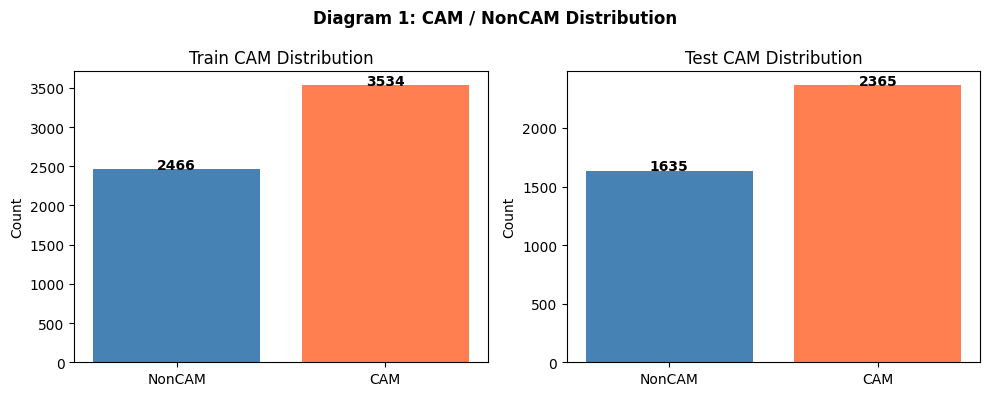

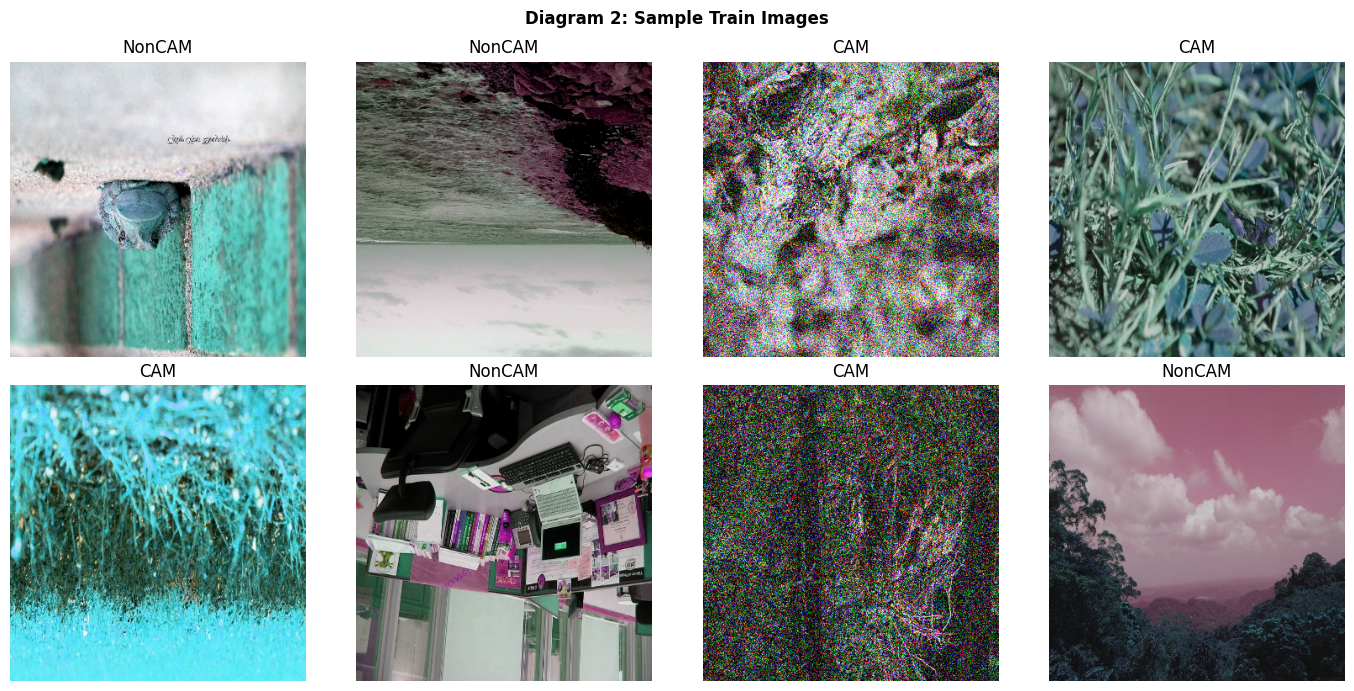

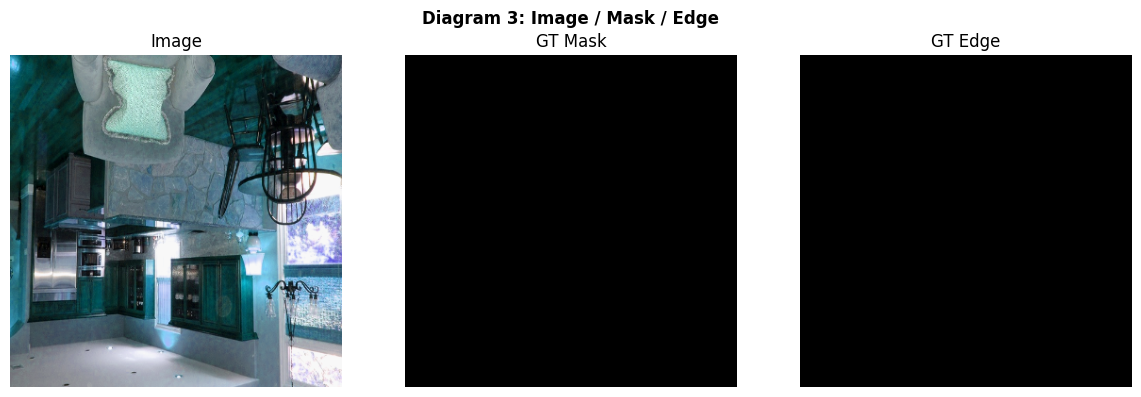

In [6]:
# Diagram 1: CAM vs NonCAM distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, cmap) in zip(axes, [('Train', train_cam_map), ('Test', test_cam_map)]):
    vals = list(cmap.values())
    counts = [sum(1-v for v in vals), sum(v for v in vals)]
    ax.bar(['NonCAM', 'CAM'], counts, color=['steelblue', 'coral'])
    ax.set_title(f'{title} CAM Distribution'); ax.set_ylabel('Count')
    for i, c in enumerate(counts): ax.text(i, c+2, str(c), ha='center', fontweight='bold')
plt.suptitle('Diagram 1: CAM / NonCAM Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag1_cam_dist.png', dpi=100); plt.show()

# Diagram 2: Sample images
n_show = 8
collected = []
for img_t, mask_t, edge_t, lbl, stem in train_dl:
    for j in range(img_t.shape[0]):
        collected.append((img_t[j], lbl[j].item()))
        if len(collected) >= n_show: break
    if len(collected) >= n_show: break

cols = 4
rows = math.ceil(len(collected) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows))
axes = np.array(axes).flatten()
for ax in axes: ax.axis('off')  # blank all first
for idx, (im, lb) in enumerate(collected):
    img_np = im.permute(1,2,0).numpy()
    img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
    axes[idx].imshow(img_np)
    axes[idx].set_title('CAM' if lb==1 else 'NonCAM')
    axes[idx].axis('off')
plt.suptitle('Diagram 2: Sample Train Images', fontweight='bold')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag2_samples.png', dpi=100); plt.show()

# Diagram 3: Sample + GT overlay
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
img_t, mask_t, edge_t, lbl, stem = next(iter(train_dl))
img_np = img_t[0].permute(1,2,0).numpy()
img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
axes[0].imshow(img_np); axes[0].set_title('Image'); axes[0].axis('off')
axes[1].imshow(mask_t[0,0].numpy(), cmap='gray'); axes[1].set_title('GT Mask'); axes[1].axis('off')
axes[2].imshow(edge_t[0,0].numpy(), cmap='gray'); axes[2].set_title('GT Edge'); axes[2].axis('off')
plt.suptitle('Diagram 3: Image / Mask / Edge', fontweight='bold')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag3_overlay.png', dpi=100); plt.show()

## Section 5: Classifier Model (PVTv2-B2 + Binary Head)

In [7]:
class CAMClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('pvt_v2_b2', pretrained=True, features_only=False, num_classes=0)
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1) if False else nn.Identity(),  # timm already pools
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        feats = self.backbone(x)  # [B, feat_dim]
        return self.head(feats)

cam_clf = CAMClassifier().to(DEVICE)
print('CAMClassifier params:', sum(p.numel() for p in cam_clf.parameters())/1e6, 'M')

model.safetensors:   0%|          | 0.00/101M [00:00<?, ?B/s]

CAMClassifier params: 24.981698 M


## Section 6: Classifier Training Loop

In [8]:
# ── Early Stopping Helper ─────────────────────────────────────────────────────
class EarlyStopping:
    """Monitors a metric (default: lower-is-better for loss, set mode='max' for acc/F1)."""
    def __init__(self, patience=10, min_delta=1e-4, mode='min', verbose=True):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score; return False
        if self.mode == 'min':
            improved = score < self.best_score - self.min_delta
        else:
            improved = score > self.best_score + self.min_delta
        if improved:
            self.best_score = score; self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'  [EarlyStopping] No improvement for {self.counter}/{self.patience} epochs.')
            if self.counter >= self.patience:
                self.stop = True
        return self.stop


# ── Classifier Training ───────────────────────────────────────────────────────
cls_opt = torch.optim.AdamW(cam_clf.parameters(), lr=CFG['cls_lr'], weight_decay=1e-4)
cls_sched = torch.optim.lr_scheduler.CosineAnnealingLR(cls_opt, T_max=CFG['cls_epochs'])
cls_criterion = torch.nn.CrossEntropyLoss()
cls_scaler = GradScaler(enabled=CFG['use_amp'])
cls_es = EarlyStopping(patience=CFG['cls_patience'], mode='max')  # monitor val acc

cls_log = []
best_cls_acc = 0.0

# Clean up labels in memory to ensure they are strictly binary (0 or 1)
def sanitize_cam_map(cam_map):
    for k in list(cam_map.keys()):
        val = int(cam_map[k])
        # If the label is a category ID > 1, clamp it to 1 (CAM)
        if val > 1:
            cam_map[k] = 1
        elif val < 0:
            cam_map[k] = 0

sanitize_cam_map(train_cam_map)
sanitize_cam_map(test_cam_map)

print(f"Sanitized Train labels: {set(train_cam_map.values())}")
print(f"Sanitized Test labels: {set(test_cam_map.values())}")

# Also recreate the dataloaders just to be absolutely certain they use the clean maps
cls_train_ds = CAMClassifierDataset(TRAIN_IMG, train_cam_map, train_aug, trial=TRIAL, trial_n=tn)
cls_val_ds   = CAMClassifierDataset(TEST_IMG,  test_cam_map,  val_aug,   trial=TRIAL, trial_n=tn//4)
cls_train_dl = DataLoader(cls_train_ds, batch_size=CFG['cls_bs'], shuffle=True,  num_workers=2, pin_memory=True)
cls_val_dl   = DataLoader(cls_val_ds,   batch_size=CFG['cls_bs'], shuffle=False, num_workers=2, pin_memory=True)
print("Dataloaders rebuilt with safe binary labels!")


print('=== STAGE 1: CAM/NonCAM Classifier Training ===')
for epoch in range(1, CFG['cls_epochs']+1):
    cam_clf.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for imgs, labels in cls_train_dl:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()   # ✅ FIX
    
        cls_opt.zero_grad()
    
        with autocast(enabled=CFG['use_amp']):
            logits = cam_clf(imgs)          # [B,2]
            loss = cls_criterion(logits, labels)
    
        cls_scaler.scale(loss).backward()
        cls_scaler.step(cls_opt)
        cls_scaler.update()
        tr_loss    += loss.item() * imgs.size(0)
        preds       = logits.argmax(1)
        tr_correct += (preds == labels).sum().item()
        tr_total   += imgs.size(0)

    cam_clf.eval()
    vl_loss, vl_correct, vl_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in cls_val_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=CFG['use_amp']):
                logits = cam_clf(imgs)
                loss   = cls_criterion(logits, labels)
            vl_loss    += loss.item() * imgs.size(0)
            preds       = logits.argmax(1)
            vl_correct += (preds == labels).sum().item()
            vl_total   += imgs.size(0)

    tr_acc = tr_correct / tr_total
    vl_acc = vl_correct / vl_total
    tr_l   = tr_loss / tr_total
    vl_l   = vl_loss / vl_total
    cls_sched.step()

    row = dict(epoch=epoch, tr_loss=tr_l, tr_acc=tr_acc, vl_loss=vl_l, vl_acc=vl_acc)
    cls_log.append(row)
    print(f'[CLS Ep {epoch:02d}] tr_loss={tr_l:.4f} tr_acc={tr_acc:.4f} | vl_loss={vl_l:.4f} vl_acc={vl_acc:.4f}')

    if vl_acc > best_cls_acc:
        best_cls_acc = vl_acc
        torch.save(cam_clf.state_dict(), CKPT_DIR/'best_cls.pth')
        print(f'  → Saved best classifier (acc={best_cls_acc:.4f})')

    if cls_es(vl_acc):
        print(f'  [EarlyStopping] Classifier stopped at epoch {epoch}.')
        break

cls_df = pd.DataFrame(cls_log)
cls_df.to_csv(LOG_DIR/'cls_log.csv', index=False)
print('Classifier training done. Best val acc:', best_cls_acc)

Sanitized Train labels: {0, 1}
Sanitized Test labels: {0, 1}


Dataloaders rebuilt with safe binary labels!
=== STAGE 1: CAM/NonCAM Classifier Training ===


[CLS Ep 01] tr_loss=0.3822 tr_acc=0.8298 | vl_loss=0.2331 vl_acc=0.9103
  → Saved best classifier (acc=0.9103)


[CLS Ep 02] tr_loss=0.2558 tr_acc=0.8937 | vl_loss=0.2017 vl_acc=0.9137


  → Saved best classifier (acc=0.9137)


...

[CLS Ep 18] tr_loss=0.0195 tr_acc=0.9933 | vl_loss=0.2818 vl_acc=0.9417


  → Saved best classifier (acc=0.9417)


[CLS Ep 19] tr_loss=0.0195 tr_acc=0.9923 | vl_loss=0.2870 vl_acc=0.9423


  → Saved best classifier (acc=0.9423)


[CLS Ep 20] tr_loss=0.0207 tr_acc=0.9923 | vl_loss=0.2864 vl_acc=0.9420
  [EarlyStopping] No improvement for 1/7 epochs.
Classifier training done. Best val acc: 0.94225


## Section 7: Diagrams 4-6 — Classifier Results

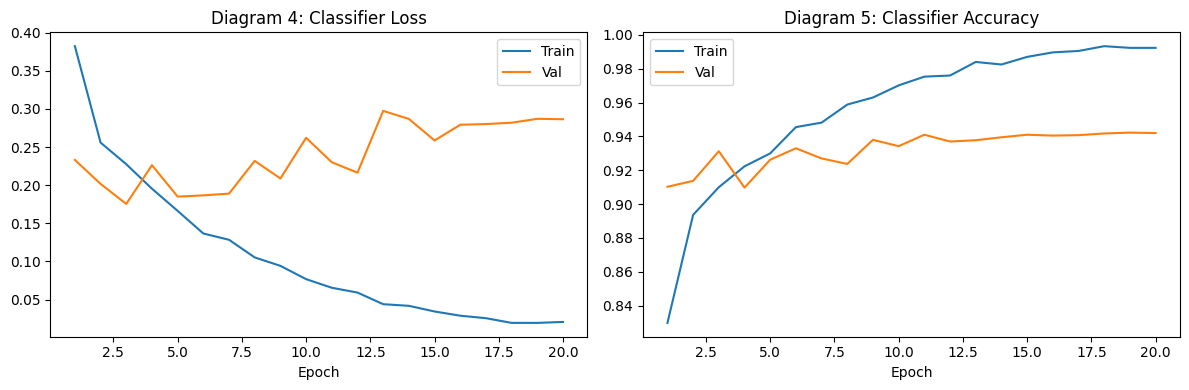

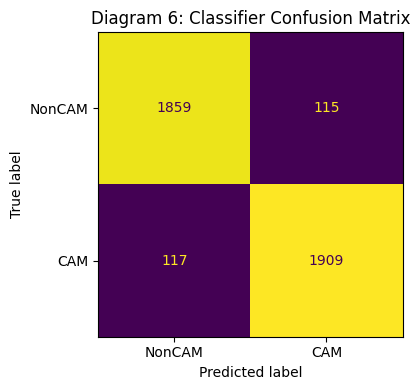

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cls_df.epoch, cls_df.tr_loss, label='Train'); axes[0].plot(cls_df.epoch, cls_df.vl_loss, label='Val')
axes[0].set_title('Diagram 4: Classifier Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(cls_df.epoch, cls_df.tr_acc,  label='Train'); axes[1].plot(cls_df.epoch, cls_df.vl_acc,  label='Val')
axes[1].set_title('Diagram 5: Classifier Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag4_5_cls_curves.png', dpi=100); plt.show()

# Diagram 6: Confusion-style prediction on val set
cam_clf.load_state_dict(torch.load(CKPT_DIR/'best_cls.pth', map_location=DEVICE))
cam_clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in cls_val_dl:
        imgs = imgs.to(DEVICE)
        preds = cam_clf(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(all_labels, all_preds, labels=[0,1])
fig, ax = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(cm, display_labels=['NonCAM','CAM']).plot(ax=ax, colorbar=False)
ax.set_title('Diagram 6: Classifier Confusion Matrix')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag6_cls_cm.png', dpi=100); plt.show()

## Section 8: Save/Load Classifier Checkpoint

In [10]:
# Load best classifier (already saved above)
cam_clf.load_state_dict(torch.load(CKPT_DIR/'best_cls.pth', map_location=DEVICE))
cam_clf.eval()
print('Best classifier loaded from', CKPT_DIR/'best_cls.pth')

Best classifier loaded from /kaggle/working/checkpoints/best_cls.pth


## Section 9: PVTv2-B4 Backbone

In [11]:
class PVTv2Backbone(nn.Module):
    """PVTv2-B4. Returns [F1, F2, F3, F4] feature maps."""
    def __init__(self, pretrained=True):
        super().__init__()
        self.model = timm.create_model(
            'pvt_v2_b4', pretrained=pretrained, features_only=True,
            out_indices=(0,1,2,3)
        )
        self.channels = self.model.feature_info.channels()  # [64,128,320,512]

    def forward(self, x):
        return self.model(x)  # list of 4 feature maps

_bb = PVTv2Backbone(pretrained=not TRIAL)
print('PVTv2-B4 channels:', _bb.channels)
del _bb

model.safetensors:   0%|          | 0.00/250M [00:00<?, ?B/s]

PVTv2-B4 channels: [64, 128, 320, 512]


## Section 10: DWT + FSA Module

In [12]:
# ── Discrete Wavelet Transform on F4 ─────────────────────────────────────────
class DWTDecomp(nn.Module):
    """2D Haar DWT → LL, LH, HL, HH subbands. Input [B,C,H,W]."""
    def forward(self, x):
        # Crop to even H and W before slicing
        H, W = x.shape[2], x.shape[3]
        x = x[:, :, :H - H%2, :W - W%2]
        x00 = x[:, :, 0::2, 0::2]
        x01 = x[:, :, 0::2, 1::2]
        x10 = x[:, :, 1::2, 0::2]
        x11 = x[:, :, 1::2, 1::2]
        LL = (x00 + x01 + x10 + x11) * 0.5
        LH = (-x00 - x01 + x10 + x11) * 0.5
        HL = (-x00 + x01 - x10 + x11) * 0.5
        HH = (x00 - x01 - x10 + x11) * 0.5
        return LL, LH, HL, HH  # each [B, C, H/2, W/2]


# ── Frequency Self-Attention (FSA) ────────────────────────────────────────────
class FSA(nn.Module):
    """
    4 subband tokens (each pooled to a scalar per band) attend over each other.
    Returns [B, 8] vector (2 scalars per band: mean+std = 8 features over 4 bands).
    """
    def __init__(self, in_ch):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(in_ch, 2)  # each band → 2-dim token
        self.attn = nn.MultiheadAttention(embed_dim=2, num_heads=2, batch_first=True)
        self.out_proj = nn.Linear(8, 8)

    def forward(self, ll, lh, hl, hh):
        bands = [ll, lh, hl, hh]
        tokens = []
        for b in bands:
            feat = self.pool(b).squeeze(-1).squeeze(-1)  # [B, C]
            tokens.append(self.proj(feat))               # [B, 2]
        tokens = torch.stack(tokens, dim=1)              # [B, 4, 2]
        out, _ = self.attn(tokens, tokens, tokens)       # [B, 4, 2]
        out = out.reshape(out.size(0), -1)               # [B, 8]
        return self.out_proj(out)                        # [B, 8]

## Section 11: FPN Decoder + Mamba Blocks

In [13]:
# ── Simple SSM (Mamba-inspired, pure PyTorch) ─────────────────────────────────
class SimpleSSM(nn.Module):
    """Simplified selective state-space model (1D along spatial sequence)."""
    def __init__(self, d_model, d_state=16, expand=2):
        super().__init__()
        d_inner = d_model * expand
        self.in_proj  = nn.Linear(d_model, d_inner * 2)
        self.conv1d   = nn.Conv1d(d_inner, d_inner, kernel_size=4, padding=3, groups=d_inner)
        self.x_proj   = nn.Linear(d_inner, d_state * 2 + d_inner)
        self.dt_proj  = nn.Linear(d_inner, d_inner)
        self.out_proj = nn.Linear(d_inner, d_model)
        self.norm     = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: [B, L, D]
        residual = x
        xz = self.in_proj(x)          # [B, L, 2*d_inner]
        x2, z = xz.chunk(2, dim=-1)   # each [B, L, d_inner]
        x2 = self.conv1d(x2.transpose(1,2))[:, :, :x.size(1)].transpose(1,2)
        x2 = F.silu(x2)
        y  = x2 * F.silu(z)
        out = self.out_proj(y)
        return self.norm(out + residual)


class MambaBlock(nn.Module):
    """Wraps SimpleSSM for 2D feature maps."""
    def __init__(self, channels):
        super().__init__()
        self.ssm = SimpleSSM(channels)

    def forward(self, x):
        B, C, H, W = x.shape
        x_seq = x.flatten(2).transpose(1, 2)   # [B, H*W, C]
        x_seq = self.ssm(x_seq)
        return x_seq.transpose(1, 2).reshape(B, C, H, W)


# ── FPN Decoder ───────────────────────────────────────────────────────────────
class FPNDecoder(nn.Module):
    def __init__(self, in_channels=(64,128,320,512), out_ch=64):
        super().__init__()
        self.lat = nn.ModuleList([nn.Conv2d(c, out_ch, 1) for c in in_channels])
        self.mamba = nn.ModuleList([MambaBlock(out_ch) for _ in in_channels])
        self.fuse  = nn.ModuleList([
            nn.Sequential(nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU())
            for _ in in_channels[:-1]
        ])

    def forward(self, feats):
        # feats: [F1,F2,F3,F4]
        lats = [self.lat[i](feats[i]) for i in range(4)]
        p = self.mamba[3](lats[3])
        outs = [p]
        for i in range(2, -1, -1):
            p = F.interpolate(p, size=lats[i].shape[2:], mode='bilinear', align_corners=False)
            p = self.fuse[i](p + lats[i])
            p = self.mamba[i](p)
            outs.append(p)
        return outs  # [P4, P3, P2, P1] (coarse→fine)

## Section 12: Quantum HQCM (PennyLane, 8-qubit)

In [14]:
class QuantumHQCM(nn.Module):
    """Hybrid Quantum-Classical Module. Input [B,8] → Output [B,8]."""
    def __init__(self, n_qubits=8, n_layers=4):
        super().__init__()
        self.n_qubits = n_qubits
        self.dev = qml.device('default.qubit', wires=n_qubits)

        @qml.qnode(self.dev, interface='torch', diff_method='backprop')
        def circuit(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        self.circuit  = circuit
        weight_shape  = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
        self.weights  = nn.Parameter(torch.randn(weight_shape) * 0.1)

        self.pre_ln   = nn.LayerNorm(n_qubits)
        self.post_ln  = nn.LayerNorm(n_qubits)

    def forward(self, x):
        # x: [B, 8]
        x = self.pre_ln(x)
        x = torch.tanh(x) * math.pi  # scale to [-π, π]
        results = []
        for i in range(x.shape[0]):
            out = self.circuit(x[i], self.weights)  # list of 8 tensors
            results.append(torch.stack(out))
        out = torch.stack(results)                  
        return self.post_ln(out.float())


class DummyHQCM(nn.Module):
    """CPU-fast stub used in TRIAL mode."""
    def __init__(self, n_qubits=8):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(n_qubits, n_qubits*4), nn.GELU(), nn.Linear(n_qubits*4, n_qubits))
        self.ln = nn.LayerNorm(n_qubits)
    def forward(self, x):
        return self.ln(self.fc(x))

def make_hqcm():
    if CFG['use_quantum']:
        return QuantumHQCM(CFG['n_qubits'], CFG['q_layers'])
    return DummyHQCM(CFG['n_qubits'])

print('HQCM mode:', 'Quantum' if CFG['use_quantum'] else 'Classical stub')

HQCM mode: Quantum


## Section 13: Dual-Domain Reverse Fusion

In [15]:
class DualDomainFusion(nn.Module):
    """
    Fuses frequency vector [B,8] with spatial FPN feature [B,C,H,W].
    Broadcasts frequency vector as channel-wise attention.
    """
    def __init__(self, spatial_ch, freq_dim=8):
        super().__init__()
        self.freq_expand = nn.Sequential(
            nn.Linear(freq_dim, spatial_ch),
            nn.Sigmoid()
        )
        self.conv = nn.Sequential(
            nn.Conv2d(spatial_ch, spatial_ch, 3, padding=1),
            nn.BatchNorm2d(spatial_ch),
            nn.ReLU()
        )

    def forward(self, spatial, freq_vec):
        # spatial: [B, C, H, W], freq_vec: [B, 8]
        attn = self.freq_expand(freq_vec)[:, :, None, None]  # [B, C, 1, 1]
        fused = spatial * attn
        return self.conv(fused + spatial)

## Section 14: Q-WaveKAN Gated Head

In [16]:
class SplineActivation(nn.Module):
    """Learnable spline-based activation approximating KAN node."""
    def __init__(self, n_knots=8):
        super().__init__()
        self.knots  = nn.Parameter(torch.linspace(-3, 3, n_knots))
        self.coeffs = nn.Parameter(torch.zeros(n_knots))

    def forward(self, x):
        # B-spline via distance weighting
        d = x.unsqueeze(-1) - self.knots.view(1, 1, 1, -1)  # works for any shape
        basis = torch.exp(-0.5 * d**2)
        spline = (basis * self.coeffs).sum(-1)
        return x + spline  # residual connection


class QWaveKANHead(nn.Module):
    """Quantum-gated KAN-based segmentation head."""
    def __init__(self, in_ch=64, freq_dim=8):
        super().__init__()
        # Quantum gate: frequency vector → channel gate
        self.q_gate = nn.Sequential(
            nn.Linear(freq_dim, in_ch),
            nn.Sigmoid()
        )
        self.spline = SplineActivation()
        self.seg_head   = nn.Conv2d(in_ch, 1, 1)
        self.uncert_head = nn.Conv2d(in_ch, 1, 1)
        self.edge_head   = nn.Conv2d(in_ch, 1, 1)

    def forward(self, feat, freq_vec):
        # feat: [B, C, H, W], freq_vec: [B, 8]
        gate = self.q_gate(freq_vec)[:, :, None, None]
        gated = self.spline(feat * gate)
        seg    = self.seg_head(gated)
        uncert = self.uncert_head(gated).abs()  # positive uncertainty
        edge   = self.edge_head(gated)
        return seg, uncert, edge

## Section 15: GradCAM Heatmap Module

In [17]:
class GradCAMHeatmap:
    """GradCAM on the last FPN output before the head."""
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._hooks       = []

    def register(self):
        self._hooks.append(self.target_layer.register_forward_hook(self._save_act))
        self._hooks.append(self.target_layer.register_full_backward_hook(self._save_grad))

    def remove(self):
        for h in self._hooks: h.remove()

    def _save_act(self, m, inp, out):
        self.activations = out.detach()

    def _save_grad(self, m, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def compute(self, img_tensor, seg_pred):
        """Returns heatmap [B,1,H,W] in [0,1]."""
        score = seg_pred.mean()
        self.model.zero_grad()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2,3), keepdim=True)  # [B, C, 1, 1]
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # [B, 1, H, W]
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=img_tensor.shape[2:], mode='bilinear', align_corners=False)
        # Normalize
        B = cam.shape[0]
        cam_flat = cam.view(B, -1)
        cam_min  = cam_flat.min(1)[0].view(B,1,1,1)
        cam_max  = cam_flat.max(1)[0].view(B,1,1,1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        return cam  # [B,1,H,W]

    @staticmethod
    def overlay(img_tensor, cam, alpha=0.5):
        """Returns np array [H,W,3] as jet overlay."""
        img_np = img_tensor[0].permute(1,2,0).cpu().numpy()
        img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])).clip(0,1)
        cam_np = cam[0,0].cpu().numpy()
        heatmap = cm.jet(cam_np)[:,:,:3]  # [H,W,3]
        overlay = alpha * heatmap + (1-alpha) * img_np
        return (overlay.clip(0,1) * 255).astype(np.uint8)

## Section 16: Full QFE-COD Model Assembly

In [18]:
class QFECOD(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.backbone = PVTv2Backbone(pretrained=pretrained)
        ch = self.backbone.channels  # [64,128,320,512]

        self.dwt = DWTDecomp()
        self.fsa = FSA(in_ch=ch[3])
        self.hqcm = make_hqcm()

        self.fpn = FPNDecoder(in_channels=ch, out_ch=64)
        self.fusion = DualDomainFusion(spatial_ch=64, freq_dim=8)
        self.head = QWaveKANHead(in_ch=64, freq_dim=8)

    def forward(self, x):
        feats = self.backbone(x)            # [F1,F2,F3,F4]

        # Frequency branch
        ll, lh, hl, hh = self.dwt(feats[3])
        freq_token = self.fsa(ll, lh, hl, hh)  # [B, 8]
        freq_vec   = self.hqcm(freq_token)      # [B, 8]

        # Spatial branch
        fpn_outs = self.fpn(feats)          # [P4,P3,P2,P1]
        fine = fpn_outs[-1]                 # P1: finest [B,64,H/4,W/4]

        # Dual-domain fusion
        fused = self.fusion(fine, freq_vec) # [B,64,H/4,W/4]

        # Prediction heads
        seg, uncert, edge = self.head(fused, freq_vec)

        # Upsample to input size
        H, W = x.shape[2:]
        seg    = F.interpolate(seg,    size=(H,W), mode='bilinear', align_corners=False)
        uncert = F.interpolate(uncert, size=(H,W), mode='bilinear', align_corners=False)
        edge   = F.interpolate(edge,   size=(H,W), mode='bilinear', align_corners=False)

        return seg, uncert, edge, fused   # fused returned for GradCAM

qfe_model = QFECOD(pretrained=not TRIAL).to(DEVICE)
n_params = sum(p.numel() for p in qfe_model.parameters())
print(f'QFE-COD params: {n_params/1e6:.2f}M')

QFE-COD params: 62.51M


## Section 17: Architecture Visualizations (Diagrams 7-11)

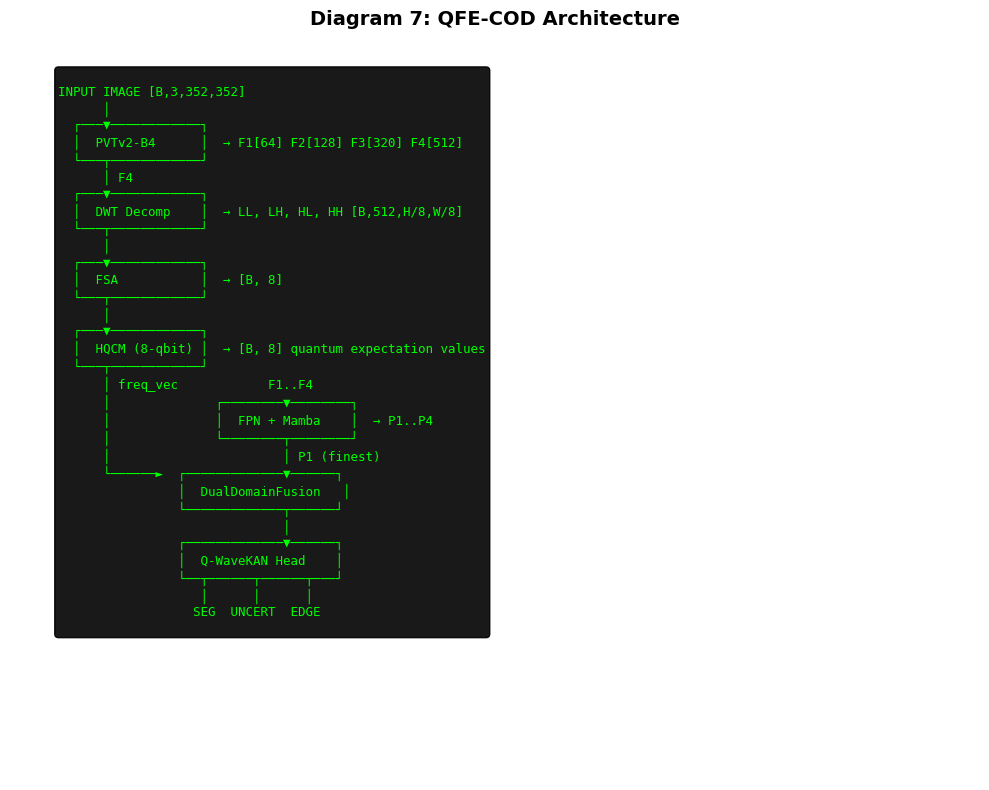

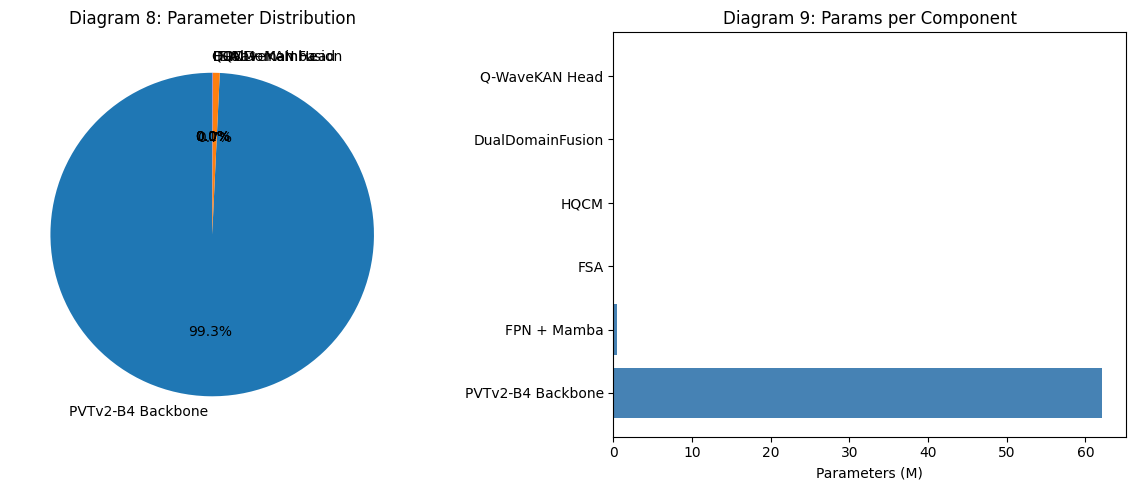

In [19]:
# Diagram 7: Architecture block diagram (text-art)
arch_text = """
INPUT IMAGE [B,3,352,352]
      │
  ┌───▼────────────┐
  │  PVTv2-B4      │  → F1[64] F2[128] F3[320] F4[512]
  └───┬────────────┘
      │ F4
  ┌───▼────────────┐
  │  DWT Decomp    │  → LL, LH, HL, HH [B,512,H/8,W/8]
  └───┬────────────┘
      │
  ┌───▼────────────┐
  │  FSA           │  → [B, 8]
  └───┬────────────┘
      │
  ┌───▼────────────┐
  │  HQCM (8-qbit) │  → [B, 8] quantum expectation values
  └───┬────────────┘
      │ freq_vec            F1..F4
      │              ┌────────▼────────┐
      │              │  FPN + Mamba    │  → P1..P4
      │              └────────┬────────┘
      │                       │ P1 (finest)
      └──────►  ┌─────────────▼──────┐
                │  DualDomainFusion   │
                └─────────────┬──────┘
                              │
                ┌─────────────▼──────┐
                │  Q-WaveKAN Head    │
                └──┬──────┬──────┬───┘
                   │      │      │
                  SEG  UNCERT  EDGE
"""
fig, ax = plt.subplots(figsize=(10,8))
ax.text(0.05, 0.95, arch_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.9), color='lime')
ax.axis('off'); ax.set_title('Diagram 7: QFE-COD Architecture', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag7_arch.png', dpi=100, bbox_inches='tight'); plt.show()

# Diagrams 8-11: Parameter breakdown
components = {
    'PVTv2-B4 Backbone': sum(p.numel() for p in qfe_model.backbone.parameters()),
    'FPN + Mamba': sum(p.numel() for p in qfe_model.fpn.parameters()),
    'FSA': sum(p.numel() for p in qfe_model.fsa.parameters()),
    'HQCM': sum(p.numel() for p in qfe_model.hqcm.parameters()),
    'DualDomainFusion': sum(p.numel() for p in qfe_model.fusion.parameters()),
    'Q-WaveKAN Head': sum(p.numel() for p in qfe_model.head.parameters()),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(list(components.values()), labels=list(components.keys()), autopct='%1.1f%%', startangle=90)
axes[0].set_title('Diagram 8: Parameter Distribution')
axes[1].barh(list(components.keys()), [v/1e6 for v in components.values()], color='steelblue')
axes[1].set_xlabel('Parameters (M)'); axes[1].set_title('Diagram 9: Params per Component')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag8_9_params.png', dpi=100); plt.show()

## Section 18: SINetV2 Baseline

In [20]:
class SINetV2(nn.Module):
    """Lightweight SINetV2 reimplementation (ResNet-50 backbone + S-MRF)."""
    def __init__(self, pretrained=True):
        super().__init__()
        backbone = timm.create_model('resnet50', pretrained=pretrained, features_only=True,
                                      out_indices=(1,2,3,4))
        self.enc  = backbone
        self.chs  = backbone.feature_info.channels()  # [256,512,1024,2048]

        # Lateral convs
        self.lat  = nn.ModuleList([nn.Conv2d(c, 64, 1) for c in self.chs])
        # Search Modules (simplified)
        self.sm   = nn.ModuleList([
            nn.Sequential(nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU())
            for _ in range(4)
        ])
        # Identification Module
        self.im   = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1, groups=64), nn.Conv2d(64, 64, 1),
            nn.BatchNorm2d(64), nn.ReLU()
        )
        self.seg_head  = nn.Conv2d(64, 1, 1)
        self.edge_head = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        feats = self.enc(x)
        lats  = [self.lat[i](feats[i]) for i in range(4)]
        p = self.sm[3](lats[3])
        for i in range(2, -1, -1):
            p = F.interpolate(p, size=lats[i].shape[2:], mode='bilinear', align_corners=False)
            p = self.sm[i](p + lats[i])
        p  = self.im(p)
        H, W = x.shape[2:]
        seg  = F.interpolate(self.seg_head(p),  (H,W), mode='bilinear', align_corners=False)
        edge = F.interpolate(self.edge_head(p), (H,W), mode='bilinear', align_corners=False)
        uncert = torch.zeros_like(seg)  # no uncertainty head in baseline
        return seg, uncert, edge, p

sinet_model = SINetV2(pretrained=not TRIAL).to(DEVICE)
print('SINetV2 params:', sum(p.numel() for p in sinet_model.parameters())/1e6, 'M')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

SINetV2 params: 23.90733 M


## Section 19: Loss Functions & Metrics

In [21]:
# ── Loss Functions ────────────────────────────────────────────────────────────
def bce_loss(pred, target):
    return F.binary_cross_entropy_with_logits(pred, target.clamp(0,1))

def dice_loss(pred, target, eps=1e-6):
    p = torch.sigmoid(pred)
    t = target.clamp(0, 1)
    inter = (p * t).sum(dim=(1,2,3))
    union = p.sum(dim=(1,2,3)) + t.sum(dim=(1,2,3))
    return 1 - (2 * inter + eps) / (union + eps)

def kl_loss(uncert, mask):
    target_uncert = (mask > 0.5).float() * 0.1 + 0.01  # near-zero uncert at high-confidence regions
    return F.mse_loss(uncert, target_uncert)

def combined_loss(seg, uncert, edge, mask_gt, edge_gt):
    l_bce   = bce_loss(seg, mask_gt)
    l_dice  = dice_loss(seg, mask_gt).mean()
    l_edge  = bce_loss(edge, edge_gt)
    l_uncert = kl_loss(uncert, mask_gt)
    return (CFG['lambda_bce']   * l_bce  +
            CFG['lambda_dice']  * l_dice +
            CFG['lambda_edge']  * l_edge +
            CFG['lambda_uncert']* l_uncert)

# ── Metrics ───────────────────────────────────────────────────────────────────
def compute_metrics(pred_logit, gt, edge_pred=None, edge_gt=None, threshold=0.5, eps=1e-6):
    pred = (torch.sigmoid(pred_logit) > threshold).float()
    gt   = gt.float()

    inter = (pred * gt).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + gt.sum(dim=(1,2,3))
    iou   = ((inter + eps) / (union - inter + eps)).mean().item()
    dice  = ((2*inter + eps) / (union + eps)).mean().item()

    mae   = (pred - gt).abs().mean().item()

    # Fβ (β=1 = F1)
    prec  = (inter + eps) / (pred.sum(dim=(1,2,3)) + eps)
    rec   = (inter + eps) / (gt.sum(dim=(1,2,3)) + eps)
    fb    = (2 * prec * rec / (prec + rec + eps)).mean().item()

    # Structure measure Sα
    mu_pred = pred.mean(dim=(1,2,3))
    mu_gt   = gt.mean(dim=(1,2,3))
    s_alpha = (1 - (mu_pred - mu_gt).abs()).clamp(0,1).mean().item()

    # E-measure Eφ (simplified)
    align = 1 - mae

    # Edge F1
    edge_f1 = 0.0
    if edge_pred is not None and edge_gt is not None:
        ep   = (torch.sigmoid(edge_pred) > threshold).float()
        eg   = edge_gt.float()
        ei   = (ep * eg).sum(dim=(1,2,3))
        eu   = ep.sum(dim=(1,2,3)) + eg.sum(dim=(1,2,3))
        edge_f1 = ((2*ei + eps) / (eu + eps)).mean().item()

    return dict(
    IoU=iou,
    Dice=dice,
    MAE=mae,
    Precision=prec.mean().item(),
    Recall=rec.mean().item(),
    Fb=fb,
    Sa=s_alpha,
    Ephi=align,
    EdgeF1=edge_f1
    )

print('Losses and metrics ready.')

Losses and metrics ready.


## Section 20: Shared Training Loop (QFE-COD + SINetV2 together)

In [22]:
# ── Optimisers ────────────────────────────────────────────────────────────────
qfe_opt   = torch.optim.AdamW(qfe_model.parameters(),   lr=CFG['lr'], weight_decay=1e-4)
sinet_opt = torch.optim.AdamW(sinet_model.parameters(), lr=CFG['lr'], weight_decay=1e-4)

qfe_sched   = torch.optim.lr_scheduler.CosineAnnealingLR(qfe_opt,   T_max=CFG['epochs'])
sinet_sched = torch.optim.lr_scheduler.CosineAnnealingLR(sinet_opt, T_max=CFG['epochs'])

scaler = GradScaler(enabled=CFG['use_amp'])

# ── GradCAM setup ─────────────────────────────────────────────────────────────
# Hook on the last Mamba block of FPN (P1 stage)
gradcam = GradCAMHeatmap(qfe_model, qfe_model.fpn.mamba[0])
gradcam.register()

# ── Early Stopping ────────────────────────────────────────────────────────────
qfe_es   = EarlyStopping(patience=CFG['patience'], min_delta=CFG['min_delta'], mode='max')  # monitor Dice
sinet_es = EarlyStopping(patience=CFG['patience'], min_delta=CFG['min_delta'], mode='max')

# ── Logging ───────────────────────────────────────────────────────────────────
history = []
best_qfe_dice   = 0.0
best_sinet_dice = 0.0

print('=== STAGE 2: QFE-COD + SINetV2 Joint Training ===')
print(f'Epochs: {CFG["epochs"]} | BS: {CFG["bs"]} | Early stopping patience: {CFG["patience"]}')

for epoch in range(1, CFG['epochs']+1):
    qfe_model.train(); sinet_model.train()
    qfe_tr_loss = sinet_tr_loss = 0.0
    n_batches = 0

    t0 = time.time()
    for imgs, masks, edges, cam_lbl, _ in train_dl:
        imgs  = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        edges = edges.to(DEVICE)

        # ── QFE-COD forward ─────────────────────────────────────────────────
        qfe_opt.zero_grad()
        with autocast(enabled=CFG['use_amp']):
            seg, uncert, edge, _ = qfe_model(imgs)
            qfe_loss = combined_loss(seg, uncert, edge, masks, edges)
        scaler.scale(qfe_loss).backward()
        scaler.step(qfe_opt); scaler.update()

        # ── SINetV2 forward ─────────────────────────────────────────────────
        sinet_opt.zero_grad()
        with autocast(enabled=CFG['use_amp']):
            s_seg, s_unc, s_edge, _ = sinet_model(imgs)
            sinet_loss = combined_loss(s_seg, s_unc, s_edge, masks, edges)
        scaler.scale(sinet_loss).backward()
        scaler.step(sinet_opt); scaler.update()

        qfe_tr_loss   += qfe_loss.item()
        sinet_tr_loss += sinet_loss.item()
        n_batches += 1

    qfe_sched.step(); sinet_sched.step()

    # ── Validation ───────────────────────────────────────────────────────────
    qfe_model.eval(); sinet_model.eval()
    qfe_m_acc   = defaultdict(float)
    sinet_m_acc = defaultdict(float)
    qfe_vl = sinet_vl = 0.0
    n_val = 0
    heatmap_saved = False

    with torch.no_grad():
        for batch_idx, (imgs, masks, edges, cam_lbl, stems) in enumerate(val_dl):
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)
            edges = edges.to(DEVICE)
            B = imgs.size(0)

            seg, uncert, edge, fused = qfe_model(imgs)
            qfe_vl += combined_loss(seg, uncert, edge, masks, edges).item()
            m = compute_metrics(seg, masks, edge, edges)
            for k, v in m.items(): qfe_m_acc[k] += v

            s_seg, s_unc, s_edge, _ = sinet_model(imgs)
            sinet_vl += combined_loss(s_seg, s_unc, s_edge, masks, edges).item()
            sm = compute_metrics(s_seg, masks, s_edge, edges)
            for k, v in sm.items(): sinet_m_acc[k] += v

            n_val += 1

    # Average metrics
    qfe_metrics   = {k: v/n_val for k,v in qfe_m_acc.items()}
    sinet_metrics = {k: v/n_val for k,v in sinet_m_acc.items()}

    # GradCAM (one batch, done outside no_grad)
    try:
        imgs_hm, masks_hm, edges_hm, _, stems_hm = next(iter(val_dl))
        imgs_hm = imgs_hm[:1].to(DEVICE)
        qfe_model.eval()
        seg_hm, _, _, _ = qfe_model(imgs_hm)
        cam_map_vis = gradcam.compute(imgs_hm, seg_hm)
        overlay_img = gradcam.overlay(imgs_hm, cam_map_vis)
        cv2.imwrite(str(VIZ_DIR/f'heatmap_ep{epoch:02d}.png'),
                    cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR))
    except Exception as e:
        pass  # GradCAM can fail if graph is freed; silently skip

    row = dict(
        epoch      = epoch,
        qfe_tr_loss   = qfe_tr_loss/n_batches,
        sinet_tr_loss = sinet_tr_loss/n_batches,
        qfe_vl_loss   = qfe_vl/n_val,
        sinet_vl_loss = sinet_vl/n_val,
        **{f'qfe_{k}': v   for k,v in qfe_metrics.items()},
        **{f'sinet_{k}': v for k,v in sinet_metrics.items()},
    )
    history.append(row)

    print(f'[Ep {epoch:02d}] '
          f'QFE loss={qfe_tr_loss/n_batches:.4f} vl={qfe_vl/n_val:.4f} '
          f'Dice={qfe_metrics["Dice"]:.4f} IoU={qfe_metrics["IoU"]:.4f} | '
          f'SIN loss={sinet_tr_loss/n_batches:.4f} vl={sinet_vl/n_val:.4f} '
          f'Dice={sinet_metrics["Dice"]:.4f} '
          f'({time.time()-t0:.0f}s)')

    # Checkpointing
    if qfe_metrics['Dice'] > best_qfe_dice:
        best_qfe_dice = qfe_metrics['Dice']
        torch.save(qfe_model.state_dict(), CKPT_DIR/'best_qfe.pth')
        print(f'  → QFE best saved (Dice={best_qfe_dice:.4f})')

    if sinet_metrics['Dice'] > best_sinet_dice:
        best_sinet_dice = sinet_metrics['Dice']
        torch.save(sinet_model.state_dict(), CKPT_DIR/'best_sinet.pth')
        print(f'  → SINet best saved (Dice={best_sinet_dice:.4f})')

    # Last checkpoints
    torch.save(qfe_model.state_dict(),   CKPT_DIR/'last_qfe.pth')
    torch.save(sinet_model.state_dict(), CKPT_DIR/'last_sinet.pth')

    # Early stopping
    qfe_stop   = qfe_es(qfe_metrics['Dice'])
    sinet_stop = sinet_es(sinet_metrics['Dice'])
    if qfe_stop and sinet_stop:
        print(f'[EarlyStopping] Both models stopped at epoch {epoch}. Exiting training loop.')
        break

gradcam.remove()
print('Training complete.')

=== STAGE 2: QFE-COD + SINetV2 Joint Training ===
Epochs: 50 | BS: 4 | Early stopping patience: 10


[Ep 01] QFE loss=1.2129 vl=0.8652 Dice=0.5788 IoU=0.5196 | SIN loss=1.3060 vl=0.9959 Dice=0.4671 (1425s)


  → QFE best saved (Dice=0.5788)
  → SINet best saved (Dice=0.4671)


[Ep 02] QFE loss=0.8751 vl=0.8025 Dice=0.6010 IoU=0.5435 | SIN loss=0.9811 vl=0.8959 Dice=0.5105 (1397s)


  → QFE best saved (Dice=0.6010)


...

[Ep 26] QFE loss=0.6538 vl=0.7179 Dice=0.7705 IoU=0.7206 | SIN loss=0.7742 vl=0.7931 Dice=0.6776 (1404s)


  [EarlyStopping] No improvement for 1/10 epochs.
  [EarlyStopping] No improvement for 3/10 epochs.


[Ep 27] QFE loss=0.6546 vl=0.7223 Dice=0.7599 IoU=0.7105 | SIN loss=0.7762 vl=0.7995 Dice=0.6843 (1410s)


  [EarlyStopping] No improvement for 2/10 epochs.
  [EarlyStopping] No improvement for 4/10 epochs.


[Ep 28] QFE loss=0.6511 vl=0.7169 Dice=0.7889 IoU=0.7402 | SIN loss=0.7733 vl=0.7837 Dice=0.6557 (1406s)


## Section 21: Per-Epoch Metrics Table + CSV

In [ ]:
hist_df = pd.DataFrame(history)
hist_df.to_csv(LOG_DIR/'training_history.csv', index=False)

# Pretty comparison table: last epoch
metrics_to_show = ['IoU','Dice','MAE','Fb','Sa','Ephi','EdgeF1']
compare = pd.DataFrame({
    'Metric'  : metrics_to_show,
    'QFE-COD' : [round(hist_df[f'qfe_{m}'].iloc[-1], 4) for m in metrics_to_show],
    'SINetV2' : [round(hist_df[f'sinet_{m}'].iloc[-1], 4) for m in metrics_to_show],
})
print('\n=== Final Epoch Comparison ===')
print(compare.to_string(index=False))
compare.to_csv(LOG_DIR/'final_comparison.csv', index=False)

## Section 22: Diagrams 12-14 — Training Curves & Metric Comparison

In [ ]:
ep = hist_df['epoch']

# Diagram 12: Loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ep, hist_df['qfe_tr_loss'], label='QFE Train')
axes[0].plot(ep, hist_df['qfe_vl_loss'], label='QFE Val', linestyle='--')
axes[0].plot(ep, hist_df['sinet_tr_loss'], label='SINet Train')
axes[0].plot(ep, hist_df['sinet_vl_loss'], label='SINet Val', linestyle='--')
axes[0].set_title('Diagram 12: Loss Curves'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, hist_df['qfe_Dice'],   label='QFE Dice')
axes[1].plot(ep, hist_df['sinet_Dice'], label='SINet Dice')
axes[1].plot(ep, hist_df['qfe_IoU'],    label='QFE IoU', linestyle='--')
axes[1].plot(ep, hist_df['sinet_IoU'],  label='SINet IoU', linestyle='--')
axes[1].set_title('Diagram 13: Dice & IoU Curves'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag12_13_curves.png', dpi=100); plt.show()

# Diagram 14: Radar comparison
from matplotlib.patches import FancyArrowPatch
metrics_r = ['IoU','Dice','Fb','Sa','Ephi','EdgeF1']
angles = np.linspace(0, 2*np.pi, len(metrics_r), endpoint=False).tolist()
angles += angles[:1]
qfe_vals   = [hist_df[f'qfe_{m}'].iloc[-1] for m in metrics_r] + [hist_df[f'qfe_{metrics_r[0]}'].iloc[-1]]
sinet_vals = [hist_df[f'sinet_{m}'].iloc[-1] for m in metrics_r] + [hist_df[f'sinet_{metrics_r[0]}'].iloc[-1]]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, qfe_vals,   'o-', linewidth=2, label='QFE-COD', color='coral')
ax.fill(angles, qfe_vals,   alpha=0.2, color='coral')
ax.plot(angles, sinet_vals, 'o-', linewidth=2, label='SINetV2', color='steelblue')
ax.fill(angles, sinet_vals, alpha=0.2, color='steelblue')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_r)
ax.set_title('Diagram 14: Radar Metric Comparison', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.savefig(VIZ_DIR/'diag14_radar.png', dpi=100, bbox_inches='tight'); plt.show()

## Section 23: Load All Checkpoints

In [ ]:
qfe_model.load_state_dict(torch.load(CKPT_DIR/'best_qfe.pth',   map_location=DEVICE))
sinet_model.load_state_dict(torch.load(CKPT_DIR/'best_sinet.pth', map_location=DEVICE))
qfe_model.eval(); sinet_model.eval()
print('Best checkpoints loaded for inference.')

## Section 24: Single-Image Inference Function

In [ ]:
@torch.no_grad()
def infer_image(img_path, model=None, threshold=0.5):
    """
    Run inference on a single image.
    Returns dict with keys: 'seg', 'edge', 'uncert', 'overlay', 'cam_label'.
    """
    model = model or qfe_model
    img   = np.array(Image.open(img_path).convert('RGB'))
    orig  = img.copy()

    aug_out = val_aug(image=img)
    inp = aug_out['image'].unsqueeze(0).float().to(DEVICE)

    # CAM/NonCAM prediction
    cam_clf.eval()
    cam_label = cam_clf(inp).argmax(1).item()

    seg, uncert, edge, fused = model(inp)
    seg_np    = torch.sigmoid(seg)[0,0].cpu().numpy()
    edge_np   = torch.sigmoid(edge)[0,0].cpu().numpy()
    uncert_np = uncert[0,0].cpu().numpy()

    seg_bin = (seg_np > threshold).astype(np.uint8) * 255

    import matplotlib.cm as cm
    hm = cm.get_cmap('jet')(seg_np)[:, :, :3]
    orig_r = cv2.resize(orig, (SZ, SZ)) / 255.0
    overlay = (0.5 * hm + 0.5 * orig_r).clip(0,1)
    overlay = (overlay * 255).astype(np.uint8)

    return dict(seg=seg_bin, edge=(edge_np*255).astype(np.uint8),
                uncert=uncert_np, overlay=overlay,
                cam_label='CAM' if cam_label == 1 else 'NonCAM')

# Quick test on first val image
sample_imgs = list(TEST_IMG.glob('*.jpg'))[:1] + list(TEST_IMG.glob('*.png'))[:1]
if sample_imgs:
    result = infer_image(sample_imgs[0])
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    raw = np.array(Image.open(sample_imgs[0]).convert('RGB').resize((SZ,SZ)))
    for ax, (title, img_np, cmap) in zip(axes, [
        ('Input', raw, None),
        ('Seg Mask', result['seg'], 'gray'),
        ('Edge', result['edge'], 'gray'),
        ('Heatmap', result['overlay'], None),
    ]):
        ax.imshow(img_np, cmap=cmap); ax.set_title(title + f'\n{result["cam_label"]}')
        ax.axis('off')
    plt.suptitle('Single Image Inference', fontweight='bold')
    plt.tight_layout(); plt.savefig(VIZ_DIR/'inference_sample.png', dpi=100); plt.show()

## Section 25: Inference Dashboard (Upload Any Image)

In [ ]:
# ── Dashboard: batch inference on test set ─────────────────────────────────
def run_dashboard(n_samples=8, model_name='qfe'):
    model = qfe_model if model_name == 'qfe' else sinet_model
    test_imgs = sorted(list(TEST_IMG.glob('*.jpg')) + list(TEST_IMG.glob('*.png')))[:n_samples]
    if not test_imgs:
        print('No test images found.'); return

    fig, axes = plt.subplots(n_samples, 4, figsize=(14, 3*n_samples))
    if n_samples == 1: axes = [axes]

    for i, ip in enumerate(test_imgs):
        result = infer_image(ip, model=model)
        stem   = ip.stem
        raw    = np.array(Image.open(ip).convert('RGB').resize((SZ,SZ)))

        # Load GT if available
        gt_path = list(TEST_GT.glob(stem + '.*'))
        if gt_path:
            gt = np.array(Image.open(gt_path[0]).convert('L').resize((SZ,SZ)))
        else:
            gt = np.zeros((SZ,SZ), np.uint8)

        for ax, (title, img_np, cmap) in zip(axes[i], [
            (f'Input [{result["cam_label"]}]', raw, None),
            ('GT Mask', gt, 'gray'),
            ('Predicted', result['seg'], 'gray'),
            ('Heatmap', result['overlay'], None),
        ]):
            ax.imshow(img_np, cmap=cmap); ax.set_title(title, fontsize=8); ax.axis('off')

    plt.suptitle(f'Diagram 15: Inference Dashboard ({model_name.upper()})', fontweight='bold', fontsize=14)
    plt.tight_layout()
    out_path = VIZ_DIR/f'diag15_dashboard_{model_name}.png'
    plt.savefig(out_path, dpi=100, bbox_inches='tight'); plt.show()
    print(f'Dashboard saved: {out_path}')

run_dashboard(n_samples=min(4, len(val_ds)), model_name='qfe')
run_dashboard(n_samples=min(4, len(val_ds)), model_name='sinet')

In [ ]:
res = infer_image(sample_imgs[0])
print(res.keys())

In [ ]:
# ===============================
# 🔥 INLINE DASHBOARD (FINAL)
# ===============================

!pip -q install gradio

import gradio as gr
import numpy as np
from PIL import Image

def predict_dashboard(img):
    img = Image.fromarray(img)
    temp_path = "/tmp/test_img.png"
    img.save(temp_path)

    result = infer_image(temp_path)

    # ✅ YOUR KEYS
    seg = np.squeeze(result["seg"])
    edge = np.squeeze(result["edge"])
    uncert = np.squeeze(result["uncert"])
    overlay = result["overlay"]
    label = result["cam_label"]

    return overlay, seg, edge, uncert, label


interface = gr.Interface(
    fn=predict_dashboard,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[
        gr.Image(label="Overlay (Final Output)"),
        gr.Image(label="Segmentation Map"),
        gr.Image(label="Edge Map"),
        gr.Image(label="Uncertainty Map"),
        gr.Textbox(label="Prediction")
    ],
    title="QFE-COD Dashboard",
    description="Camouflaged Object Detection with Seg + Edge + Uncertainty"
)

interface.launch(inline=True)

## Section 26: Final Summary

In [ ]:
import os

print(os.listdir("checkpoints"))

In [ ]:
print('=' * 60)
print('TRAINING SUMMARY')
print('=' * 60)
print(f'TRIAL mode: {TRIAL}')
print(f'Quantum:    {CFG["use_quantum"]}')
print(f'Epochs run: {len(history)}')
print(f'Best QFE-COD  Dice: {best_qfe_dice:.4f}')
print(f'Best SINetV2  Dice: {best_sinet_dice:.4f}')
print()
print('Final Comparison:')
print(compare.to_string(index=False))
print()
print('Output files:')
for p in sorted(list(VIZ_DIR.iterdir()) + list(LOG_DIR.iterdir()) + list(CKPT_DIR.iterdir())):
    print(' ', p)
print('=' * 60)